# 02 Frequency Distributions

This chapter introduces frequency distributions, one of the most fundamental tools in descriptive statistics.

A frequency distribution organizes data by showing how often values or groups of values appear.

## Learning Objectives

After completing this chapter, you will be able to:

- calculate frequencies for categorical variables;
- calculate relative and cumulative frequencies;
- group quantitative data into class intervals;
- create and interpret a histogram;
- explain how class width affects the appearance of a distribution.

## Statistical Concepts

### Frequency

A **frequency** is the number of times a value or category appears in a dataset.

### Relative Frequency

A **relative frequency** expresses a frequency as a proportion of the total number of observations.

$$
\text{Relative Frequency}
=
\frac{\text{Frequency of a category}}{\text{Total number of observations}}
$$

### Cumulative Frequency

A **cumulative frequency** is the running total of frequencies up to a value or class interval.

### Class Interval

Continuous quantitative data are often grouped into intervals such as:

- 4.0 to less than 5.0;
- 5.0 to less than 6.0;
- 6.0 to less than 7.0.

The intervals make the overall shape of the distribution easier to understand.

## Sample Dataset

The dataset contains 40 fictional countries divided into four fictional regions.

The `happiness_score` variable is a synthetic score ranging approximately from 3 to 9. The values do not represent real countries or official happiness statistics.

| Variable | Type | Meaning |
|---|---|---|
| `country_id` | Categorical | Fictional country identifier |
| `region` | Categorical | Fictional regional group |
| `happiness_score` | Quantitative, continuous | Synthetic happiness score |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Find the repository root from either the repository root or notebooks/.
current_dir = Path.cwd().resolve()
candidates = [current_dir, *current_dir.parents]
project_root = next((path for path in candidates if (path / "data").is_dir()), None)

if project_root is None:
    raise FileNotFoundError(
        "Could not find the project root containing the data directory."
    )

data_path = project_root / "data" / "02_frequency_distributions.csv"

print(f"Project root: {project_root}")
print(f"Data path: {data_path}")

Project root: E:\Analytics\Statistical-Analytics
Data path: E:\Analytics\Statistical-Analytics\data\02_frequency_distributions.csv


In [3]:
df = pd.read_csv(data_path)
df.head()

,country_id,region,happiness_score
0,Country_01,Region_A,7.2
1,Country_02,Region_A,6.3
2,Country_03,Region_A,7.5
3,Country_04,Region_A,7.6
4,Country_05,Region_A,5.7


## Inspect the Dataset

Before constructing a frequency distribution, confirm the number of observations, column names, data types, and missing values.

In [4]:
print(f"Observations: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Observations: 40
Variables: 3

Column names:
['country_id', 'region', 'happiness_score']

Data types:
country_id          object
region              object
happiness_score    float64
dtype: object

Missing values:
country_id         0
region             0
happiness_score    0
dtype: int64


## Frequency Distribution for a Categorical Variable

For a categorical variable such as `region`, each category already defines a group.

The following table shows how many fictional countries belong to each region.

In [5]:
region_frequency = (
    df["region"]
    .value_counts()
    .sort_index()
    .rename("frequency")
    .to_frame()
)

region_frequency

,frequency
region,
Region_A,10
Region_B,10
Region_C,10
Region_D,10


## Relative Frequency

Relative frequency makes it easier to compare categories because it expresses each frequency as a proportion or percentage of the total.

In [6]:
region_frequency["relative_frequency"] = (
    region_frequency["frequency"] / region_frequency["frequency"].sum()
)

region_frequency["percentage"] = (
    region_frequency["relative_frequency"] * 100
).round(1)

region_frequency

,frequency,relative_frequency,percentage
region,,,
Region_A,10,0.25,25.0
Region_B,10,0.25,25.0
Region_C,10,0.25,25.0
Region_D,10,0.25,25.0


## Bar Chart for Categorical Frequencies

A bar chart is suitable for categorical data. Each bar represents one distinct category.

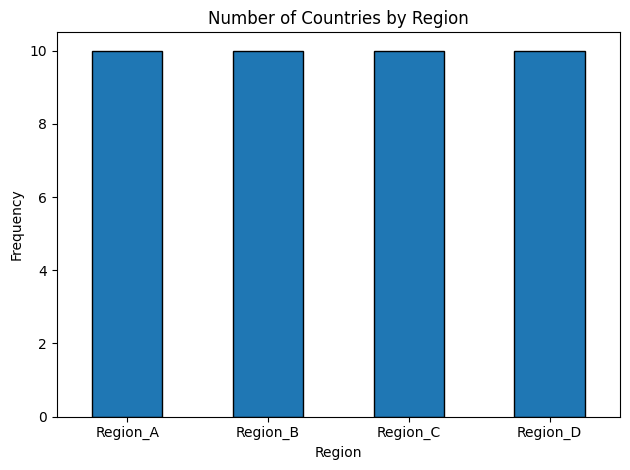

In [7]:
region_frequency["frequency"].plot(
    kind="bar",
    edgecolor="black",
)

plt.title("Number of Countries by Region")
plt.xlabel("Region")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Frequency Distribution for a Quantitative Variable

The happiness scores are quantitative and can take many possible values.

To summarize them, we divide the scale into class intervals:

- 3.0 to less than 4.0;
- 4.0 to less than 5.0;
- 5.0 to less than 6.0;
- and so on.

The `right=False` argument means the left endpoint is included and the right endpoint is excluded. For example, `[5.0, 6.0)` includes 5.0 but not 6.0.

In [8]:
bins = [3, 4, 5, 6, 7, 8, 9]

df["happiness_class"] = pd.cut(
    df["happiness_score"],
    bins=bins,
    right=False,
    include_lowest=True,
)

df[["country_id", "happiness_score", "happiness_class"]].head(10)

,country_id,happiness_score,happiness_class
0,Country_01,7.2,"[7, 8)"
1,Country_02,6.3,"[6, 7)"
2,Country_03,7.5,"[7, 8)"
3,Country_04,7.6,"[7, 8)"
4,Country_05,5.7,"[5, 6)"
5,Country_06,6.2,"[6, 7)"
6,Country_07,7.1,"[7, 8)"
7,Country_08,6.8,"[6, 7)"
8,Country_09,7.0,"[7, 8)"
9,Country_10,6.4,"[6, 7)"


In [9]:
happiness_frequency = (
    df["happiness_class"]
    .value_counts(sort=False)
    .rename("frequency")
    .to_frame()
)

happiness_frequency["relative_frequency"] = (
    happiness_frequency["frequency"]
    / happiness_frequency["frequency"].sum()
)

happiness_frequency["percentage"] = (
    happiness_frequency["relative_frequency"] * 100
).round(1)

happiness_frequency["cumulative_frequency"] = (
    happiness_frequency["frequency"].cumsum()
)

happiness_frequency["cumulative_percentage"] = (
    happiness_frequency["percentage"].cumsum()
).round(1)

happiness_frequency

,frequency,relative_frequency,percentage,cumulative_frequency,cumulative_percentage
happiness_class,,,,,
"[3, 4)",0,0.000,0.0,0,0.0
"[4, 5)",6,0.150,15.0,6,15.0
"[5, 6)",15,0.375,37.5,21,52.5
"[6, 7)",14,0.350,35.0,35,87.5
"[7, 8)",5,0.125,12.5,40,100.0
"[8, 9)",0,0.000,0.0,40,100.0


## Check the Frequency Table

A well-constructed frequency table should satisfy two checks:

1. the frequencies add up to the total number of observations;
2. the relative frequencies add up to 1, apart from small rounding differences.

In [10]:
print("Total frequency:")
print(happiness_frequency["frequency"].sum())

print("\nTotal relative frequency:")
print(happiness_frequency["relative_frequency"].sum())

Total frequency:
40

Total relative frequency:
1.0


## Histogram

A histogram visualizes the distribution of quantitative data.

Unlike a bar chart, the bars touch because the class intervals represent adjacent ranges on a numerical scale.

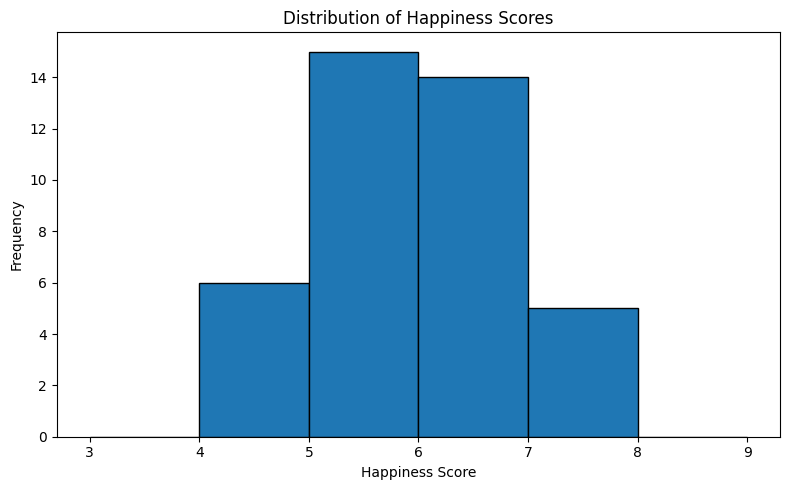

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["happiness_score"],
    bins=bins,
    edgecolor="black",
)

plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.tight_layout()
plt.show()

## Compare Different Numbers of Bins

The shape of a histogram depends partly on the chosen class intervals.

Too few bins can hide important detail. Too many bins can make the distribution look noisy, especially when the dataset is small.

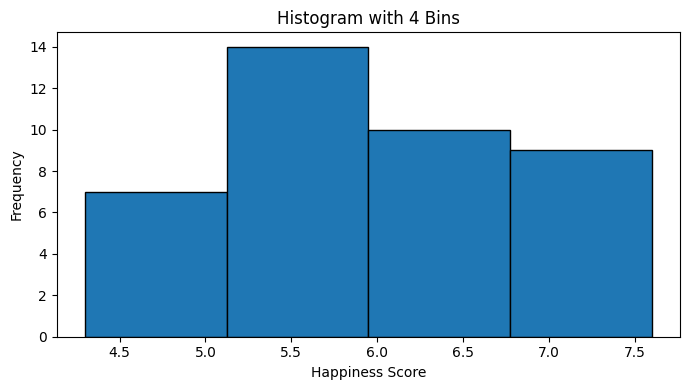

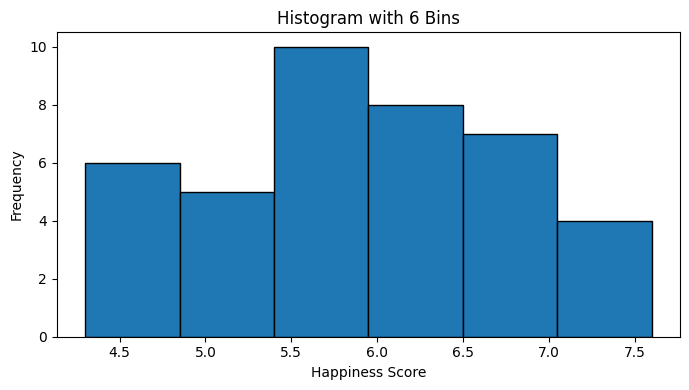

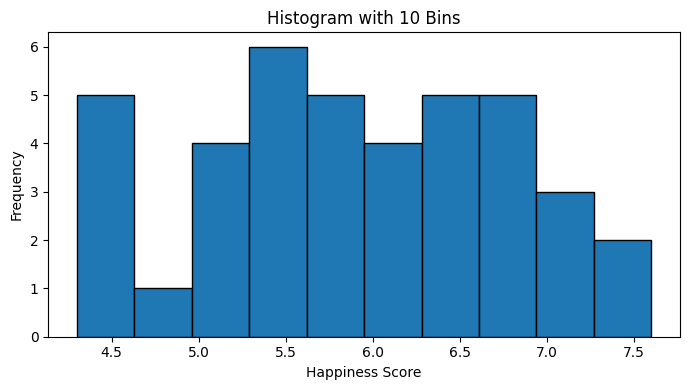

In [12]:
for number_of_bins in [4, 6, 10]:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df["happiness_score"],
        bins=number_of_bins,
        edgecolor="black",
    )

    plt.title(f"Histogram with {number_of_bins} Bins")
    plt.xlabel("Happiness Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Interpretation

From the grouped frequency table and histogram, we can examine:

- which interval contains the largest number of countries;
- whether low or high scores are relatively rare;
- whether the observations are concentrated near the center;
- how the visual impression changes when the number of bins changes.

The histogram describes the **shape of the sample distribution**. It does not prove why the scores differ between countries.

## Exercises

### Exercise 1

Use the frequency table to identify the most common happiness-score interval.

### Exercise 2

Calculate the number and percentage of countries with a happiness score of at least 7.0.

### Exercise 3

Create class intervals with a width of 0.5 instead of 1.0. Compare the resulting frequency table with the original table.

### Exercise 4

Create a bar chart showing the relative frequency of each region.

### Exercise 5

Explain in your own words why a histogram is more appropriate than a bar chart for `happiness_score`.

## Summary

In this chapter, you learned how to:

- count observations using frequencies;
- express frequencies as proportions and percentages;
- calculate cumulative frequencies;
- group continuous values into class intervals;
- visualize a quantitative distribution with a histogram;
- recognize that the choice of bins affects the appearance of a histogram.

Frequency distributions provide the foundation for the measures of central tendency introduced in the next chapter.